In [1]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

# Import 
import os
import sys
import cortex
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# Personal imports
sys.path.append("{}/../../analysis_code/utils".format(os.getcwd()))
from settings_utils import load_settings
from pycortex_utils import set_pycortex_config_file, load_surface_pycortex, get_rois, make_image_pycortex, draw_cortex

In [2]:
main_dir = '/Users/uriel/disks/meso_shared'
project_dir = 'RetinoMaps'

In [3]:
# Load settings
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
settings = load_settings([settings_path, prf_settings_path])
analysis_info = settings[0]

vert_dist_th = analysis_info['vertex_pcm_rad']
formats = analysis_info['formats']
maps_names_css_stats = analysis_info['maps_names_css_stats']
maps_names_pcm = analysis_info['maps_names_pcm']
subjects = analysis_info['subjects']
prf_task_names = analysis_info['analysis_task_names']
preproc_prep = analysis_info['preproc_prep']
filtering = analysis_info['filtering']
normalization = analysis_info['normalization']
avg_methods = analysis_info['avg_methods']
rois_methods = analysis_info['rois_methods']
pycortex_subject_template = analysis_info['pycortex_subject_template']
averaging_templates = analysis_info['averaging_templates']
formats_conversion = analysis_info['formats_conversion'] 

In [4]:
subject = 'sub-01'
pycortex_subject = 'sub-hcp1.6mm'
# pycortex_subject = subject

format_ = '170k'
surf_format = '59k'
prf_task_name = 'pRF'
hemis = ['hemi-L', 'hemi-R']

avg_method = analysis_info['avg_methods'][1]
rois_method_format = analysis_info['rois_methods'][format_][0]

In [5]:
# Set pycortex db and colormaps
cortex_dir = "{}/{}/derivatives/pp_data/cortex".format(main_dir, project_dir)
set_pycortex_config_file(cortex_dir)

In [6]:
# Load pRF results
prf_dir = "{}/{}/derivatives/pp_data/{}/{}/prf".format(
    main_dir, project_dir, subject, format_)
fit_dir = "{}/fit".format(prf_dir)
prf_deriv_dir = "{}/prf_derivatives".format(prf_dir)


if format_ == 'fsnative':
    # initial settings
    pycortex_subject = subject
    surf_format = format_

    # Derivatives                    
    deriv_fn_L = '{}/{}_task-{}_hemi-L_{}_{}_{}_{}_prf-css_deriv.func.gii'.format(
        prf_deriv_dir, subject, prf_task_name, 
        preproc_prep, filtering, normalization, avg_method)
    deriv_fn_R = '{}/{}_task-{}_hemi-R_{}_{}_{}_{}_prf-css_deriv.func.gii'.format(
        prf_deriv_dir, subject, prf_task_name, 
        preproc_prep, filtering, normalization, avg_method)
    print(f'Loading:\t{deriv_fn_L}\n\t\t{deriv_fn_R}')
    results = load_surface_pycortex(L_fn=deriv_fn_L, 
                                    R_fn=deriv_fn_R, 
                                    return_img=True)
    deriv_mat = results['data_concat'] 
    img_L = results['img_L'] 
    img_R = results['img_R']

    # Stats
    stats_fn_L = '{}/{}_task-{}_hemi-L_{}_{}_{}_{}_prf-css_stats.func.gii'.format(
        prf_deriv_dir, subject, prf_task_name, 
        preproc_prep, filtering, normalization, avg_method)
    stats_fn_R = '{}/{}_task-{}_hemi-R_{}_{}_{}_{}_prf-css_stats.func.gii'.format(
        prf_deriv_dir, subject, prf_task_name, 
        preproc_prep, filtering, normalization, avg_method)
    print(f'Loading:\t{stats_fn_L}\n\t\t{stats_fn_R}')
    stats_results = load_surface_pycortex(L_fn=stats_fn_L, 
                                          R_fn=stats_fn_R)
    stats_mat = stats_results['data_concat']

    # pCM
    pcm_fn_L = '{}/{}_task-{}_hemi-L_{}_{}_{}_{}_{}_prf-css_pcm.func.gii'.format(
        prf_deriv_dir, subject, prf_task_name, 
        preproc_prep, filtering, normalization, avg_method, rois_method_format)
    pcm_fn_R = '{}/{}_task-{}_hemi-R_{}_{}_{}_{}_{}_prf-css_pcm.func.gii'.format(
        prf_deriv_dir, subject, prf_task_name, 
        preproc_prep, filtering, normalization, avg_method, rois_method_format)
    print(f'Loading:\t{pcm_fn_L}\n\t\t{pcm_fn_R}')
    pcm_results = load_surface_pycortex(L_fn=pcm_fn_L, 
                                          R_fn=pcm_fn_R)
    pcm_mat = pcm_results['data_concat']
    
elif format_ == '170k':
    # initial settings
    pycortex_subject = pycortex_subject_template
    # surf_format = formats_conversion[format_]
    
    # Derivatives
    deriv_fn = '{}/{}_task-{}_{}_{}_{}_{}_prf-css_deriv.dtseries.nii'.format(
        prf_deriv_dir, subject, prf_task_name,
        preproc_prep, filtering, normalization, avg_method)
    print(f'Loading:\t{deriv_fn}')
    results = load_surface_pycortex(brain_fn=deriv_fn,
                                    return_img=True,
                                    return_59k_mask=True,  
                                    return_source_data=True)
    deriv_mat = results['data_concat']
    mask_59k = results['mask_59k']
    deriv_mat_170k = results['source_data'] 
    img = results['img']
    
    # Stats
    stats_fn = '{}/{}_task-{}_{}_{}_{}_{}_prf-css_stats.dtseries.nii'.format(
        prf_deriv_dir, subject, prf_task_name,
        preproc_prep, filtering, normalization, avg_method)
    print(f'Loading:\t{stats_fn}')
    stats_results = load_surface_pycortex(brain_fn=stats_fn)
    stats_mat = stats_results['data_concat']

        
    # pcm
    pcm_fn = '{}/{}_task-{}_{}_{}_{}_{}_{}_prf-css_pcm.dtseries.nii'.format(
                        prf_deriv_dir, subject, prf_task_name,
                        preproc_prep, filtering, normalization, avg_method, rois_method_format)
    print(f'Loading:\t{pcm_fn}')
    pcm_results = load_surface_pycortex(brain_fn=pcm_fn)
    pcm_mat = pcm_results['data_concat']

# Combine deriv, stats and pcm mat
deriv_mat = np.concatenate((deriv_mat, stats_mat, pcm_mat))


Loading:	/Users/uriel/disks/meso_shared/RetinoMaps/derivatives/pp_data/sub-01/170k/prf/prf_derivatives/sub-01_task-pRF_fmriprep_dct_z-score_loo-avg_prf-css_deriv.dtseries.nii
Loading:	/Users/uriel/disks/meso_shared/RetinoMaps/derivatives/pp_data/sub-01/170k/prf/prf_derivatives/sub-01_task-pRF_fmriprep_dct_z-score_loo-avg_prf-css_stats.dtseries.nii
Loading:	/Users/uriel/disks/meso_shared/RetinoMaps/derivatives/pp_data/sub-01/170k/prf/prf_derivatives/sub-01_task-pRF_fmriprep_dct_z-score_loo-avg_rois-group-mmp_prf-css_pcm.dtseries.nii


In [7]:
if 'loo' in avg_method:
    maps_names_css = analysis_info['maps_names_css_loo']
else:
    maps_names_css = analysis_info['maps_names_css']
# Maps settings 
for idx, col_name in enumerate(maps_names_css + maps_names_css_stats + maps_names_pcm):
    exec("{}_idx = idx".format(col_name))
if 'loo' in avg_method: rsq_idx2use = prf_loo_rsq_idx
else: rsq_idx2use = prf_rsq_idx

# Threshold data
deriv_mat_th = deriv_mat
amp_down = deriv_mat_th[amplitude_idx,...] > 0
rsq_down = deriv_mat_th[rsq_idx2use,...] >= analysis_info['rsqr_th']
size_th_down = deriv_mat_th[prf_size_idx,...] >= analysis_info['size_th'][0]
size_th_up = deriv_mat_th[prf_size_idx,...] <= analysis_info['size_th'][1]
ecc_th_down = deriv_mat_th[prf_ecc_idx,...] >= analysis_info['ecc_th'][0]
ecc_th_up = deriv_mat_th[prf_ecc_idx,...] <= analysis_info['ecc_th'][1]
n_th_down = deriv_mat_th[prf_n_idx,...] >= analysis_info['n_th'][0]
n_th_up = deriv_mat_th[prf_n_idx,...] <= analysis_info['n_th'][1]
if analysis_info['stats_th'] == 0.05: stats_th_down = deriv_mat_th[corr_pvalue_5pt_idx,...] <= 0.05
elif analysis_info['stats_th'] == 0.01: stats_th_down = deriv_mat_th[corr_pvalue_1pt_idx,...] <= 0.01
all_th = np.array((amp_down, rsq_down, size_th_down, size_th_up, ecc_th_down, 
                   ecc_th_up,n_th_down, n_th_up,stats_th_down)) 
deriv_mat[rsq_idx2use, np.logical_and.reduce(all_th)==False]=0

# Ripley function

In [8]:
def compute_ripley_scatter(prf_x_neighbors, prf_y_neighbors, prf_r2_neighbors,
                            R_max, n_r=100):
    """
    Compute Ripley's L-based scatter index for a single vertex.
    
    Parameters
    ----------
    prf_x_neighbors, prf_y_neighbors : (N,) arrays — pRF centers of cortical neighbors
    prf_r2_neighbors                 : (N,) array  — R² weights of neighbors
    R_max                            : float        — integration limit (degrees)
    n_r                              : int          — number of r steps (default 100)

    Returns
    -------
    scatter_i   : float        — scalar scatter index (degrees²)
    r_values    : (n_r,)       — r grid (degrees)
    L_r         : (n_r,)       — L_A(r) values
    L_minus_r   : (n_r,)       — L_A(r) - r (the deviation curve)
    pair_dists  : (N*(N-1)/2,) — all pRF distances between neighbor pairs
    pair_weights: (N*(N-1)/2,) — corresponding weights (w_j * w_k)
    """
    N = len(prf_x_neighbors)

    # --- r grid ---
    r_values = np.linspace(0, R_max, n_r)

    # --- All pairwise pRF distances between neighbors ---
    coords = np.stack([prf_x_neighbors, prf_y_neighbors], axis=1)  # (N, 2)
    pair_dists = pdist(coords)  # (N*(N-1)/2,)

    # --- Pair weights: w_j * w_k ---
    w = prf_r2_neighbors
    W_matrix = np.outer(w, w)
    pair_weights = W_matrix[np.triu_indices(N, k=1)]
    W_total = pair_weights.sum()

    # --- Ripley's L_A(r) ---
    A = np.pi * R_max**2
    L_r = np.zeros(n_r)
    for i, r in enumerate(r_values):
        inside = pair_dists < r
        weighted_count = pair_weights[inside].sum()
        K_r = (A / W_total) * weighted_count
        L_r[i] = np.sqrt(K_r / np.pi)

    L_minus_r = L_r - r_values

    # --- Scalar ---
    scatter_i = np.trapezoid(L_minus_r, r_values)

    return scatter_i, r_values, L_r, L_minus_r, pair_dists, pair_weights

# Step 1 : get list of vertices wihin roi and x cm radius

In [9]:
# Get surfaces for each hemisphere
surfs = [cortex.polyutils.Surface(*d) for d in cortex.db.get_surf(pycortex_subject, "flat")]
surf_lh, surf_rh = surfs[0], surfs[1]

# Get the vertices number per hemisphere
lh_vert_num, rh_vert_num = surf_lh.pts.shape[0], surf_rh.pts.shape[0]

In [10]:
rois = ['V1', 'V2', 'V3']
# rois = list(analysis_info[rois_method_format].keys())
hemi = 'hemi-L'

if hemi == 'hemi-L':
    surf = surf_lh
    deriv_mat_hemi = deriv_mat[:, :lh_vert_num]
elif hemi == 'hemi-R':
    surf = surf_rh
    deriv_mat_hemi = deriv_mat[:, lh_vert_num:]

In [11]:
# get roi mask
roi_verts_dict = get_rois(pycortex_subject, 
                          surf_format=surf_format, 
                          rois_type=rois_method_format,
                          mask=True, 
                          rois=rois, 
                          hemis=hemi)

In [12]:
%%time
# --- Init storage ---
results = {hemi: {roi: {
    'vert_indices': [],
    'scatter_i':    [],
    'r_values':     [],
    'L_r':          [],
    'L_minus_r':    [],
    'pair_dists':   [],
    'pair_weights': []
} for roi in rois} for hemi in hemis}

scatter_i_brain_list = []

for hemi in hemis:
    if hemi == 'hemi-L':
        surf = surf_lh
        deriv_mat_hemi = deriv_mat[:, :lh_vert_num]
    elif hemi == 'hemi-R':
        surf = surf_rh
        deriv_mat_hemi = deriv_mat[:, lh_vert_num:]

    scatter_i_hemi_array = np.full(deriv_mat_hemi.shape[1], np.nan)

    for roi in rois:
        roi_mask    = roi_verts_dict[roi]
        roi_indices = np.where(roi_mask)[0]

        for vert_idx in roi_indices:
            # --- Geodesic neighbors ---
            try:
                geo_patch = surf.get_geodesic_patch(radius=vert_dist_th, vertex=vert_idx)
            except Exception as e:
                print(f"Vertex #{vert_idx}: error: {e} within {vert_dist_th} mm")
                geo_patch['vertex_mask'] = np.zeros(surf.pts.shape[0], dtype=bool)
                geo_patch['geodesic_distance'] = []

            vertex_mask = geo_patch['vertex_mask']

            # --- Restrict to ROI ---
            vertex_mask_roi     = vertex_mask & roi_mask
            vertex_mask_roi_idx = np.where(vertex_mask_roi)[0]

            # --- Extract neighbors ---
            prf_x_neighbors  = deriv_mat_hemi[prf_x_idx,    vertex_mask_roi_idx]
            prf_y_neighbors  = deriv_mat_hemi[prf_y_idx,    vertex_mask_roi_idx]
            prf_r2_neighbors = deriv_mat_hemi[rsq_idx2use,  vertex_mask_roi_idx]
            cmf_vertex       = deriv_mat_hemi[pcm_median_idx, vert_idx]
            
            if cmf_vertex <= 0:
                continue

            # R_max from vertex CMF
            R_max = vert_dist_th #/ cmf_vertex   # mm / (mm/deg) = deg
            
            # Filtre R²=0
            r2_mask          = prf_r2_neighbors > 0
            prf_x_neighbors  = prf_x_neighbors[r2_mask]
            prf_y_neighbors  = prf_y_neighbors[r2_mask]
            prf_r2_neighbors = prf_r2_neighbors[r2_mask]
            
            if len(prf_x_neighbors) < 10:
                continue
            
            # --- Ripley scatter ---
            scatter_i, r_values, L_r, L_minus_r, pair_dists, pair_weights = compute_ripley_scatter(
                prf_x_neighbors  = prf_x_neighbors,
                prf_y_neighbors  = prf_y_neighbors,
                prf_r2_neighbors = prf_r2_neighbors,
                R_max            = R_max
            )

            # --- Store in results ---
            results[hemi][roi]['vert_indices'].append(vert_idx)
            results[hemi][roi]['scatter_i'].append(scatter_i)
            results[hemi][roi]['r_values'].append(r_values)
            results[hemi][roi]['L_r'].append(L_r)
            results[hemi][roi]['L_minus_r'].append(L_minus_r)
            results[hemi][roi]['pair_dists'].append(pair_dists)
            results[hemi][roi]['pair_weights'].append(pair_weights)

            # --- Store in hemi array ---
            scatter_i_hemi_array[vert_idx] = scatter_i

        # --- Convert fixed-size to arrays ---
        results[hemi][roi]['vert_indices'] = np.array(results[hemi][roi]['vert_indices'])
        results[hemi][roi]['scatter_i']    = np.array(results[hemi][roi]['scatter_i'])
        results[hemi][roi]['r_values']     = np.array(results[hemi][roi]['r_values'])   # (n_verts, 100)
        results[hemi][roi]['L_r']          = np.array(results[hemi][roi]['L_r'])        # (n_verts, 100)
        results[hemi][roi]['L_minus_r']    = np.array(results[hemi][roi]['L_minus_r'])  # (n_verts, 100)

    scatter_i_brain_list.append(scatter_i_hemi_array)

# --- Final brain array (hemi-L puis hemi-R) ---
scatter_i_brain_array = np.concatenate(scatter_i_brain_list)  # (total_verts,)

CPU times: user 3min 3s, sys: 12.7 s, total: 3min 16s
Wall time: 3min 5s


# Plot

## Flatmaps

In [13]:
alpha_range = [0,1]

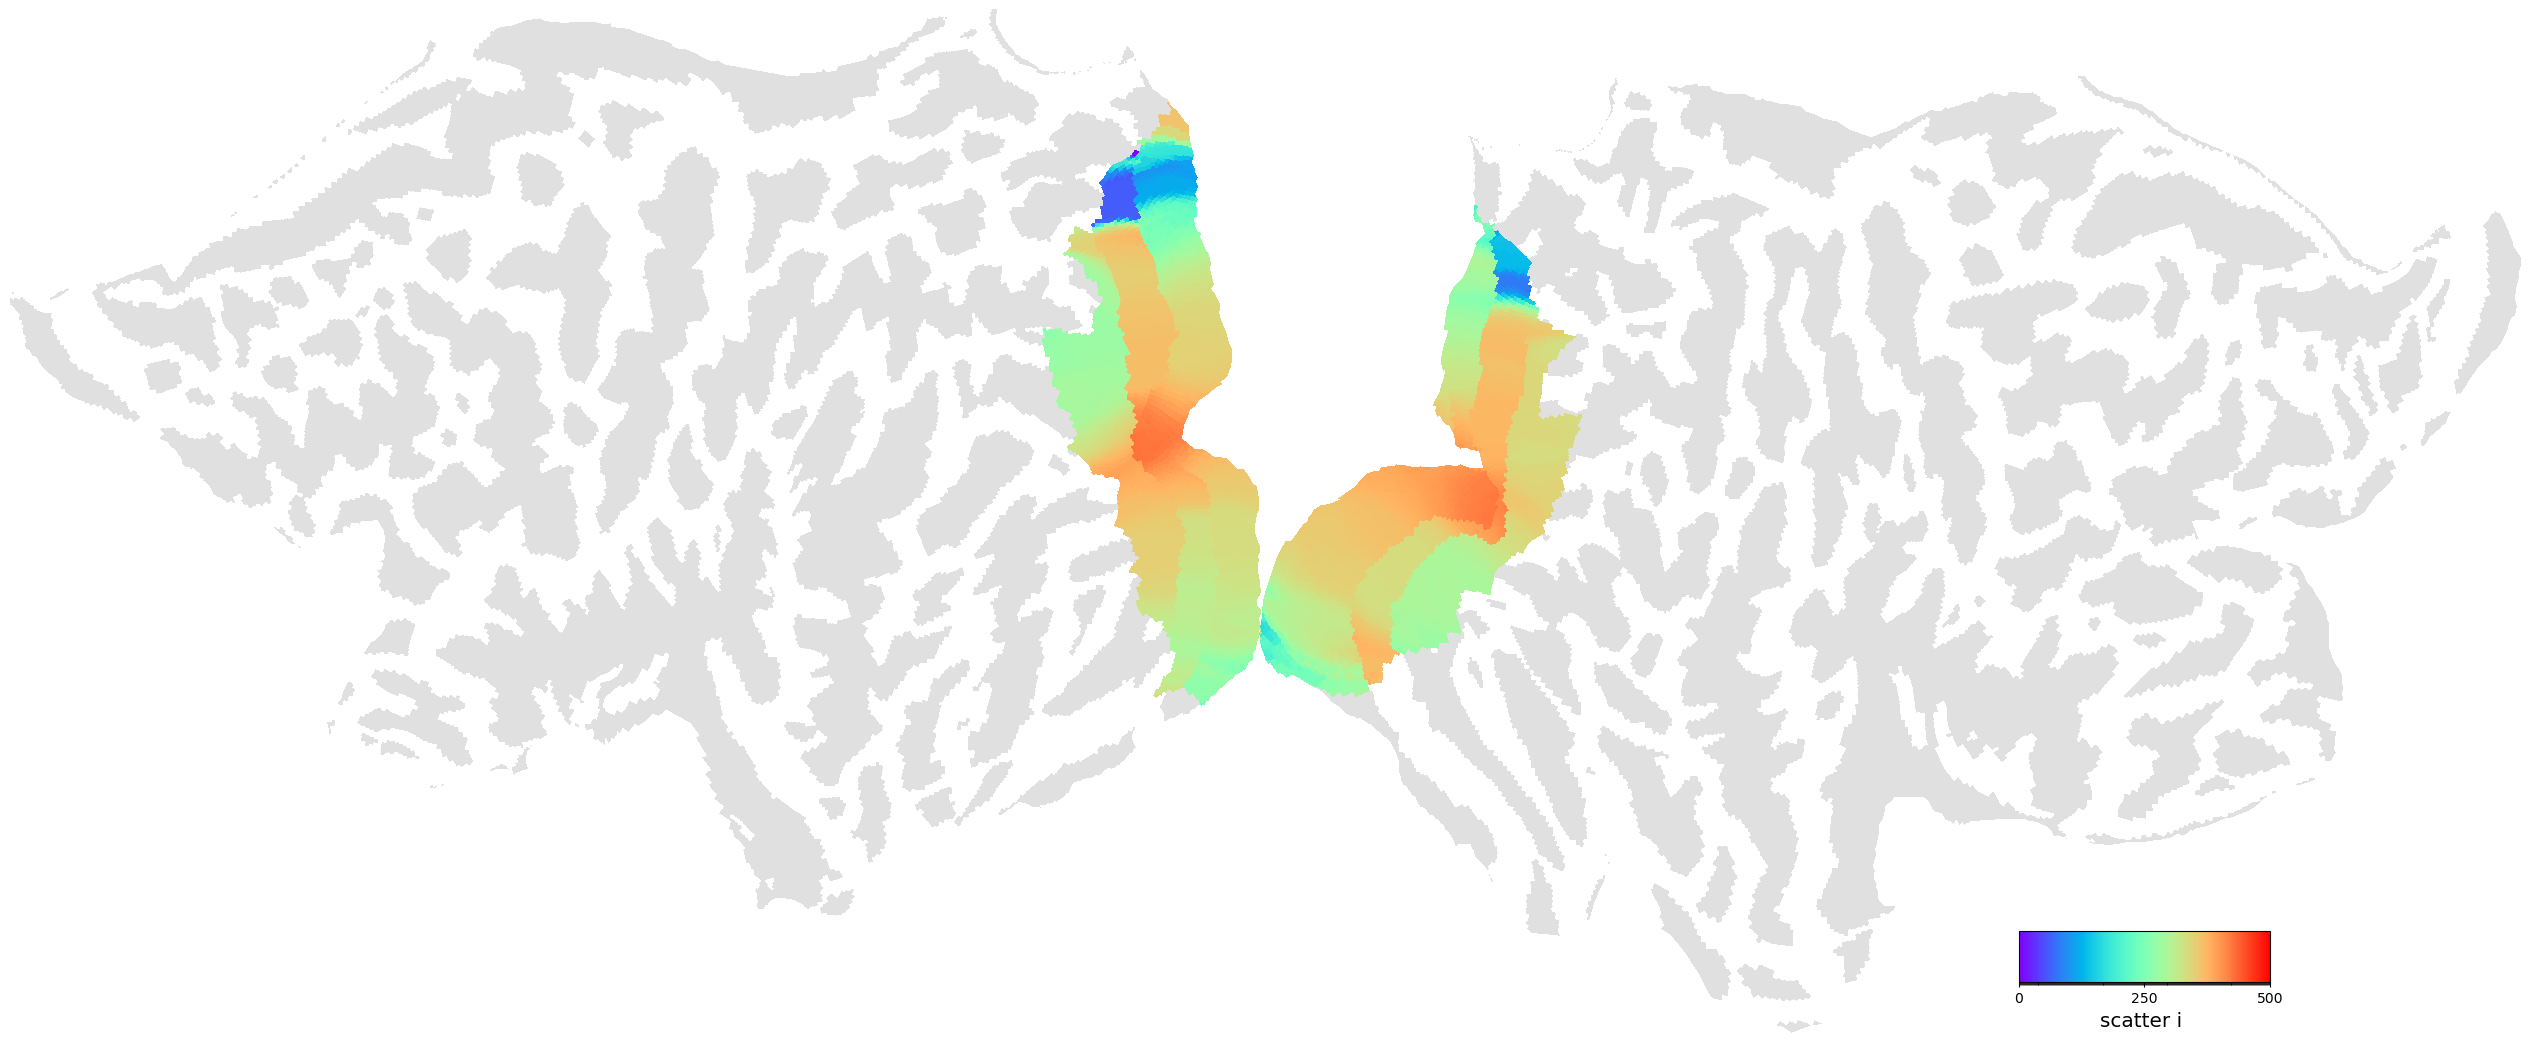

In [16]:
loo_rsq_data = deriv_mat[rsq_idx2use,:]
# alpha = loo_rsq_data
alpha = (~np.isnan(scatter_i_brain_array)).astype(int)

# loo_rsq_data = np.where(
#     np.isnan(scatter_i_brain_array),
#     0,
#     deriv_mat[rsq_idx2use, :]
# )

# alpha = loo_rsq_data
alpha_range = [0,1]
alpha = (alpha - alpha_range[0]) / (alpha_range[1] - alpha_range[0])
alpha[alpha>1]=1

# put alpha to 0 outside non interest roi 

auc_params = {
             'subject': pycortex_subject,
             'data': scatter_i_brain_array, 
             'cmap': 'rainbow', 
             'alpha': alpha, 
             'vmin': 0, 
             'vmax': 500, 
             'cbar': 'discrete', 
             'cortex_type': 'VertexRGB', 
             'description': 'CSS pRF CM',
             'curv_brightness': 1, 
             'curv_contrast': 0.25, 
             'add_roi': False, 
             'cbar_label': 'scatter i ',
             'with_labels': True}
volume_amp = draw_cortex(**auc_params)
plt.savefig('/Users/uriel/Downloads/scatter_i.png')

In [27]:
scatter_i_brain_array

array([         nan,          nan, 259.66875594, ...,          nan,
                nan,          nan], shape=(118584,))

## plot

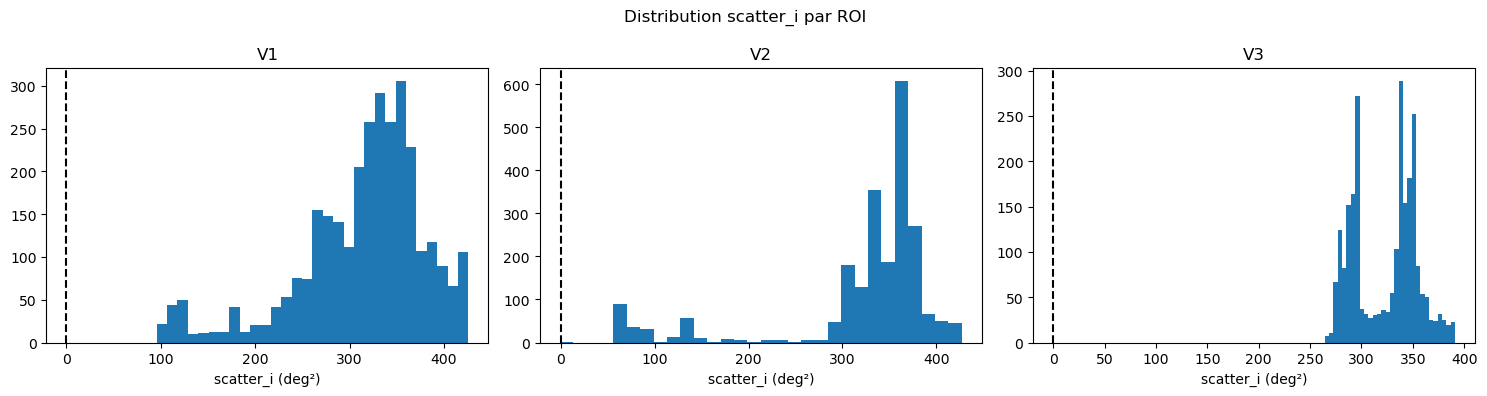

In [17]:
fig, axes = plt.subplots(1, len(rois), figsize=(15, 4))
for ax, roi in zip(axes, rois):
    vals = np.concatenate([results[hemi][roi]['scatter_i'] for hemi in hemis])
    ax.hist(vals, bins=30)
    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(roi)
    ax.set_xlabel('scatter_i (deg²)')
plt.suptitle('Distribution scatter_i par ROI')
plt.tight_layout()
plt.savefig('/Users/uriel/Downloads/Distribution_scatter_i.png', dpi=150, bbox_inches='tight')

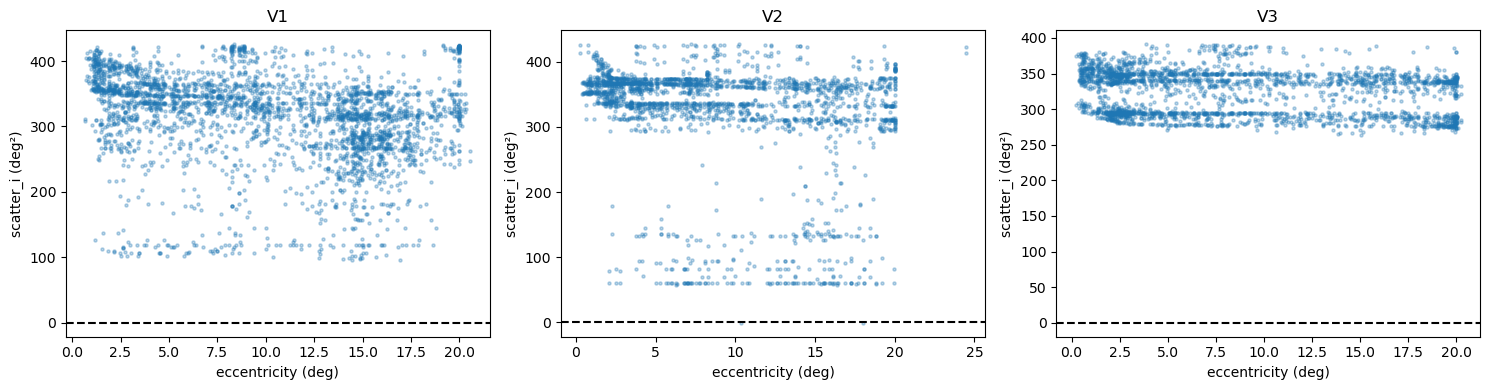

In [18]:
fig, axes = plt.subplots(1, len(rois), figsize=(15, 4))
for ax, roi in zip(axes, rois):
    scatter_vals = np.concatenate([results[hemi][roi]['scatter_i'] for hemi in hemis])
    vert_indices = np.concatenate([results[hemi][roi]['vert_indices'] for hemi in hemis])
    ecc_vals     = deriv_mat[prf_ecc_idx, vert_indices]
    ax.scatter(ecc_vals, scatter_vals, alpha=0.3, s=5)
    ax.axhline(0, color='k', linestyle='--')
    ax.set_xlabel('eccentricity (deg)')
    ax.set_ylabel('scatter_i (deg²)')
    ax.set_title(roi)
plt.tight_layout()
plt.savefig('/Users/uriel/Downloads/scatter_i_ecc.png', dpi=150, bbox_inches='tight')

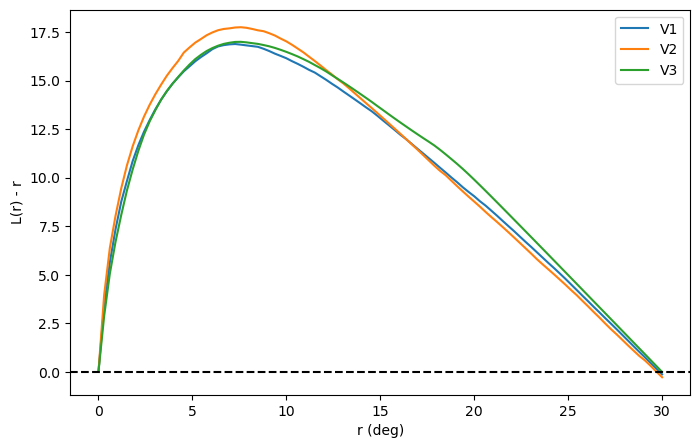

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
for roi in rois:
    L_minus_r_all = np.concatenate([results[hemi][roi]['L_minus_r'] for hemi in hemis])
    r_all         = np.concatenate([results[hemi][roi]['r_values'] for hemi in hemis])
    L_minus_r_mean = np.nanmean(L_minus_r_all, axis=0)
    r_mean         = np.nanmean(r_all, axis=0)
    ax.plot(r_mean, L_minus_r_mean, label=roi)
ax.axhline(0, color='k', linestyle='--')
ax.set_xlabel('r (deg)')
ax.set_ylabel('L(r) - r')
ax.legend()
plt.savefig('/Users/uriel/Downloads/lr_r.png', dpi=150, bbox_inches='tight')

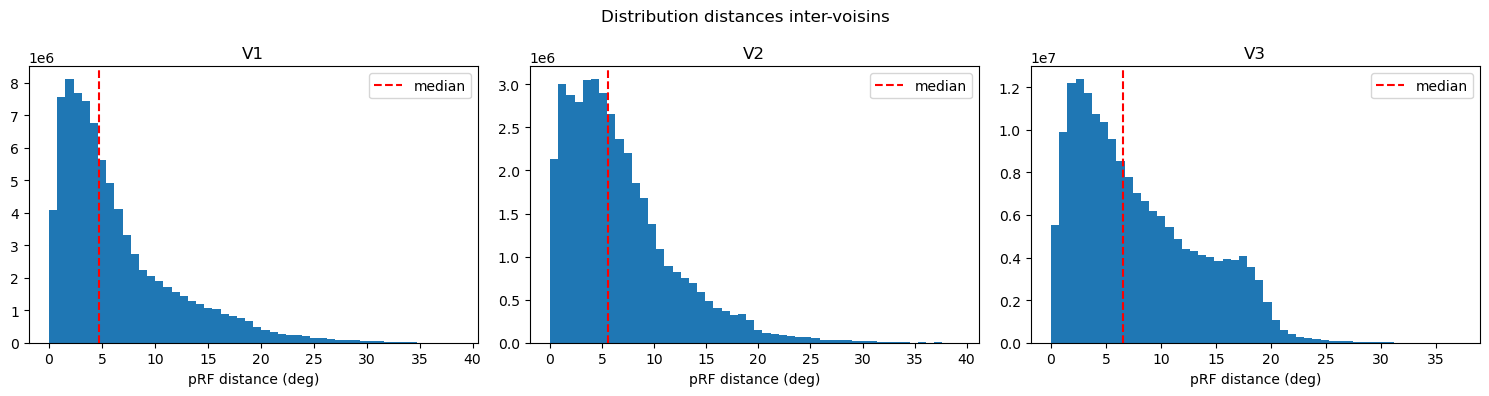

In [20]:
fig, axes = plt.subplots(1, len(rois), figsize=(15, 4))
for ax, roi in zip(axes, rois):
    all_dists = np.concatenate([
        dist for hemi in hemis for dist in results[hemi][roi]['pair_dists']
    ])
    ax.hist(all_dists, bins=50)
    ax.axvline(np.median(all_dists), color='r', linestyle='--', label='median')
    ax.set_xlabel('pRF distance (deg)')
    ax.set_title(roi)
    ax.legend()
plt.suptitle('Distribution distances inter-voisins')
plt.tight_layout()
plt.savefig('/Users/uriel/Downloads/Distribution_d_inter_voisin.png', dpi=150, bbox_inches='tight')

In [19]:
for roi in rois:
    n_pairs = [len(d) for hemi in hemis for d in results[hemi][roi]['pair_dists']]
    n_verts = [int((1 + np.sqrt(1 + 8*n)) / 2) for n in n_pairs]
    print(f"{roi}: median N voisins = {np.median(n_verts):.0f}, min = {np.min(n_verts)}")

V1: median N voisins = 192, min = 21
V2: median N voisins = 193, min = 10
V3: median N voisins = 402, min = 14


# Brouillon

In [12]:
# Loop over rois
for roi in rois : 
    roi_mask = roi_verts_dict[roi]
    roi_indices = np.where(roi_mask)[0]
    for vert_idx in roi_indices:
        # find neigbors vertices in radius 
        try :
            geo_patch = surf.get_geodesic_patch(radius=vert_dist_th, 
                                                vertex=vert_idx)
        except Exception as e:
            print("Vertex #{}: error: {} within {} mm".format(vert_idx, e, vert_dist_th))
            geo_patch['vertex_mask'] = np.zeros(surf.pts.shape[0]).astype(bool)
            geo_patch['geodesic_distance'] = []

        # extract neigboors and correponding geodesic distance 
        vertex_mask = geo_patch['vertex_mask']
        geodesic_distance = geo_patch['geodesic_distance']
        
        # Extract neighboors and correponding geodesic distance only in roi 
        vertex_mask_roi = vertex_mask & roi_mask
        vertex_mask_roi_idx = np.where(vertex_mask_roi)[0]
        idx_in_geodesic = roi_mask[vertex_mask]
        geodesic_distance_roi = geodesic_distance[idx_in_geodesic]

        prf_x_vert = deriv_mat_hemi[prf_x_idx, vert_idx]
        prf_y_vert = deriv_mat_hemi[prf_y_idx, vert_idx]
        
        prf_x_neighbors = deriv_mat_hemi[prf_x_idx, vertex_mask_roi_idx]  # shape: (n_neighbors,)
        prf_y_neighbors = deriv_mat_hemi[prf_y_idx, vertex_mask_roi_idx]
        
        prf_dist_array = np.sqrt((prf_x_vert - prf_x_neighbors)**2 + (prf_y_vert - prf_y_neighbors)**2)

        prf_x_neighbors = deriv_mat_hemi[prf_x_idx, vertex_mask_roi_idx]  # shape (N,)
        prf_y_neighbors = deriv_mat_hemi[prf_y_idx, vertex_mask_roi_idx]  # shape (N,)
        prf_r2_neighbors    = deriv_mat_hemi[prf_rsq_idx, vertex_mask_roi_idx] # shape (N,)

        scatter_i, r_values, L_r, L_minus_r, pair_dists, pair_weights = compute_ripley_scatter(
        prf_x_neighbors = deriv_mat_hemi[prf_x_idx, vertex_mask_roi_idx],
        prf_y_neighbors  = deriv_mat_hemi[prf_y_idx, vertex_mask_roi_idx],
        prf_r2_neighbors = deriv_mat_hemi[prf_rsq_idx, vertex_mask_roi_idx],
        ecc_vertex       = deriv_mat_hemi[prf_ecc_idx, vert_idx]
    )
            
